## About

**1.** We perform exploratory data analysis. This includes creating statistical summaries and charts, testing for anomalies, checking for correlations and other relations between variables, and other EDA elements.

**2.** We perform statistical inference. This includes defining the target population, forming multiple statistical hypotheses and constructing confidence intervals, setting the significance levels, conducting z or t-tests for these hypotheses.

**3.** We apply various machine learning models to predict the TravelInsurance column using the other features. This includes hyperparameter tuning, model ensembling, the analysis of model selection, and other methods.

**Dataset:**

- [Travel Insurance Prediction Data](https://www.kaggle.com/datasets/tejashvi14/travel-insurance-prediction-data)

**Context:**

A Tour & Travels Company Is Offering Travel Insurance Package To Their Customers.
The New Insurance Package Also Includes Covid Cover.
The Company Requires To Know The Which Customers Would Be Interested To Buy It Based On Its Database History.
The Insurance Was Offered To Some Of The Customers In 2019 And The Given Data Has Been Extracted From The Performance/Sales Of The Package During That Period.
The Data Is Provided For Almost 2000 Of Its Previous Customers And You Are Required To Build An Intelligent Model That Can Predict If The Customer Will Be Interested To Buy The Travel Insurance Package Based On Certain Parameters Given Below.

**Goal:**

The primary objective is to build a predictive classification model that identifies customers most likely to purchase the travel insurance package, by analyzing historical data from 2019 - our given dataset.

## Imports

In [1]:
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.proportion import proportions_ztest, proportion_confint
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, precision_recall_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay
import optuna
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE
from consts import TRAVEL_INSURANCE_DATASET

## Load the dataset and Overview of the dataset

We use a copy of our dataset to leave the original one untouched.

In [2]:
shutil.copy(TRAVEL_INSURANCE_DATASET, "datasets/TravelInsurancePredictionCopy.csv")
travel_data = pd.read_csv("datasets/TravelInsurancePredictionCopy.csv", index_col=0)

In [3]:
travel_data.head()

,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,31,Government Sector,Yes,400000,6,1,No,No,0
1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


In [4]:
travel_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1987 entries, 0 to 1986
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Age                  1987 non-null   int64 
 1   Employment Type      1987 non-null   object
 2   GraduateOrNot        1987 non-null   object
 3   AnnualIncome         1987 non-null   int64 
 4   FamilyMembers        1987 non-null   int64 
 5   ChronicDiseases      1987 non-null   int64 
 6   FrequentFlyer        1987 non-null   object
 7   EverTravelledAbroad  1987 non-null   object
 8   TravelInsurance      1987 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 155.2+ KB


We see that the dataset consists of 1987 entries and 9 columns.

## Data Cleaning

Checking for missing values.

In [5]:
travel_data.isna().mean() * 100

Age                    0.0
Employment Type        0.0
GraduateOrNot          0.0
AnnualIncome           0.0
FamilyMembers          0.0
ChronicDiseases        0.0
FrequentFlyer          0.0
EverTravelledAbroad    0.0
TravelInsurance        0.0
dtype: float64

We see that no values are missing.

Now let's check for duplicate rows and columns:

In [6]:
print(travel_data.duplicated().any())

travel_data_t = travel_data.T
print(travel_data_t.duplicated().any())

True
False


We observe duplicate rows and no duplicate columns. 

The question now is how to handle them.

**Decision:** Since those identical customer profiles can cause problems later when splitting our dataset into test and train, and those are probably real duplicates, we drop them to be safe.

In [7]:
n_drows = travel_data.duplicated().sum()
print(f"Rows before dropping duplicates: {len(travel_data)}")
print(f"Number of duplicate rows (before): {n_drows}")

travel_data = travel_data.drop_duplicates().reset_index(drop=True)

print(f"Rows after dropping duplicates: {len(travel_data)}")
print(f"Number of duplicate rows (after): {travel_data.duplicated().sum()}")

Rows before dropping duplicates: 1987
Number of duplicate rows (before): 738
Rows after dropping duplicates: 1249
Number of duplicate rows (after): 0


## EDA

Before modeling, we check **distributions**, **outliers/anomalies**, and **relationships**. This helps us pick appropriate tests/models (e.g., whether a t-test is appropriate, whether scaling matters, whether extreme values dominate).

We start by taking a look at our target variable `TravelInsurance` - Whether The Customer Bought The Travel Insurance Or Not. 

We examine the distribution to check for **class imbalance**.

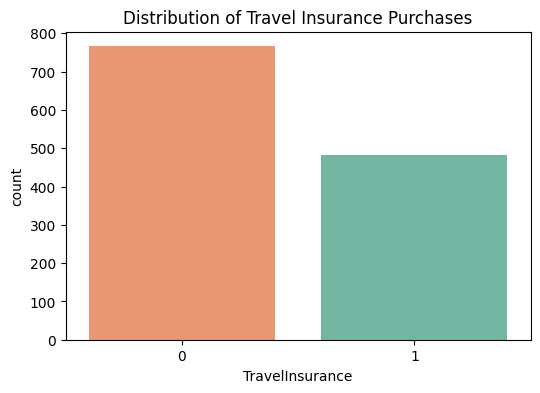

                 count  share
TravelInsurance              
0                  766  0.613
1                  483  0.387


In [8]:
plt.figure(figsize=(6, 4))
colors = sns.color_palette("Set2", n_colors=2)
colors = colors[::-1]

sns.countplot(x='TravelInsurance', data=travel_data, palette=colors, hue='TravelInsurance', legend=False)
plt.title('Distribution of Travel Insurance Purchases')
plt.show()

y_counts = travel_data['TravelInsurance'].value_counts().sort_index()
y_props = travel_data['TravelInsurance'].value_counts(normalize=True).sort_index()
print(pd.DataFrame({'count': y_counts, 'share': y_props.round(3)}))

We see that ones that bought the Travel Insurance are underrepresented. 
483 bought the insurance - 39%, while 766 didn't - 61%.

We handle and consider that later.

We now take a look at the general **correlations** of the **numeric** input variables to the output variable - TravelInsurance.

In [9]:
numeric_data = travel_data.select_dtypes("int64")
travel_corr_q = numeric_data.corr()["TravelInsurance"]
travel_corr_q

Age                0.067536
AnnualIncome       0.293913
FamilyMembers      0.084907
ChronicDiseases   -0.010015
TravelInsurance    1.000000
Name: TravelInsurance, dtype: float64

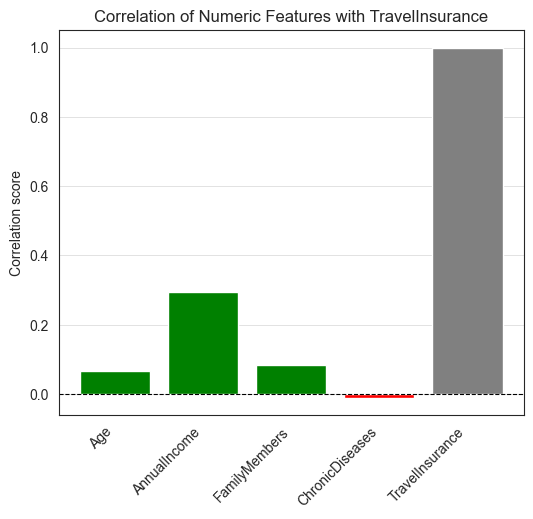

In [10]:
sns.set_style("white")
x = range(len(travel_corr_q))

plt.figure(figsize=(6, 5))
colors = [
    "grey" if var == "TravelInsurance" else ("green" if val > 0 else "red")
    for var, val in travel_corr_q.items()
]
plt.bar(
    x,
    travel_corr_q,
    capsize=5,
    color=colors,
)
plt.xticks(x, travel_corr_q.index, rotation=45, ha="right")
plt.axhline(0, color="black", linewidth=0.8, linestyle="--")
plt.ylabel("Correlation score")
plt.title("Correlation of Numeric Features with TravelInsurance")
plt.grid(axis="y", alpha=0.8, linestyle="-", linewidth=0.5)
plt.gca().set_facecolor("white")
plt.gcf().patch.set_facecolor("white")
plt.show()

We observe that there are no strong correlations (|r| > 0.7), neither moderate correlations (|r| > 0.5) between the independent variables and our target variable.

Positive Correlations:

AnnualIncome yields a weak positive correlations (r ≈ 0.3), suggesting a slight tendency toward buying an insurance with higher income.

Negligible Correlations:

Age and FamilyMembers show virtually no relationship with buying a travel insurance (|r| < 0.08), indicating these variables have minimal influence on a travel insurance purchase.
Chronic Diseases similarly shows negligible correlations.

We now inspect how the **categorical features** are each correlated or reflected in the target variable.

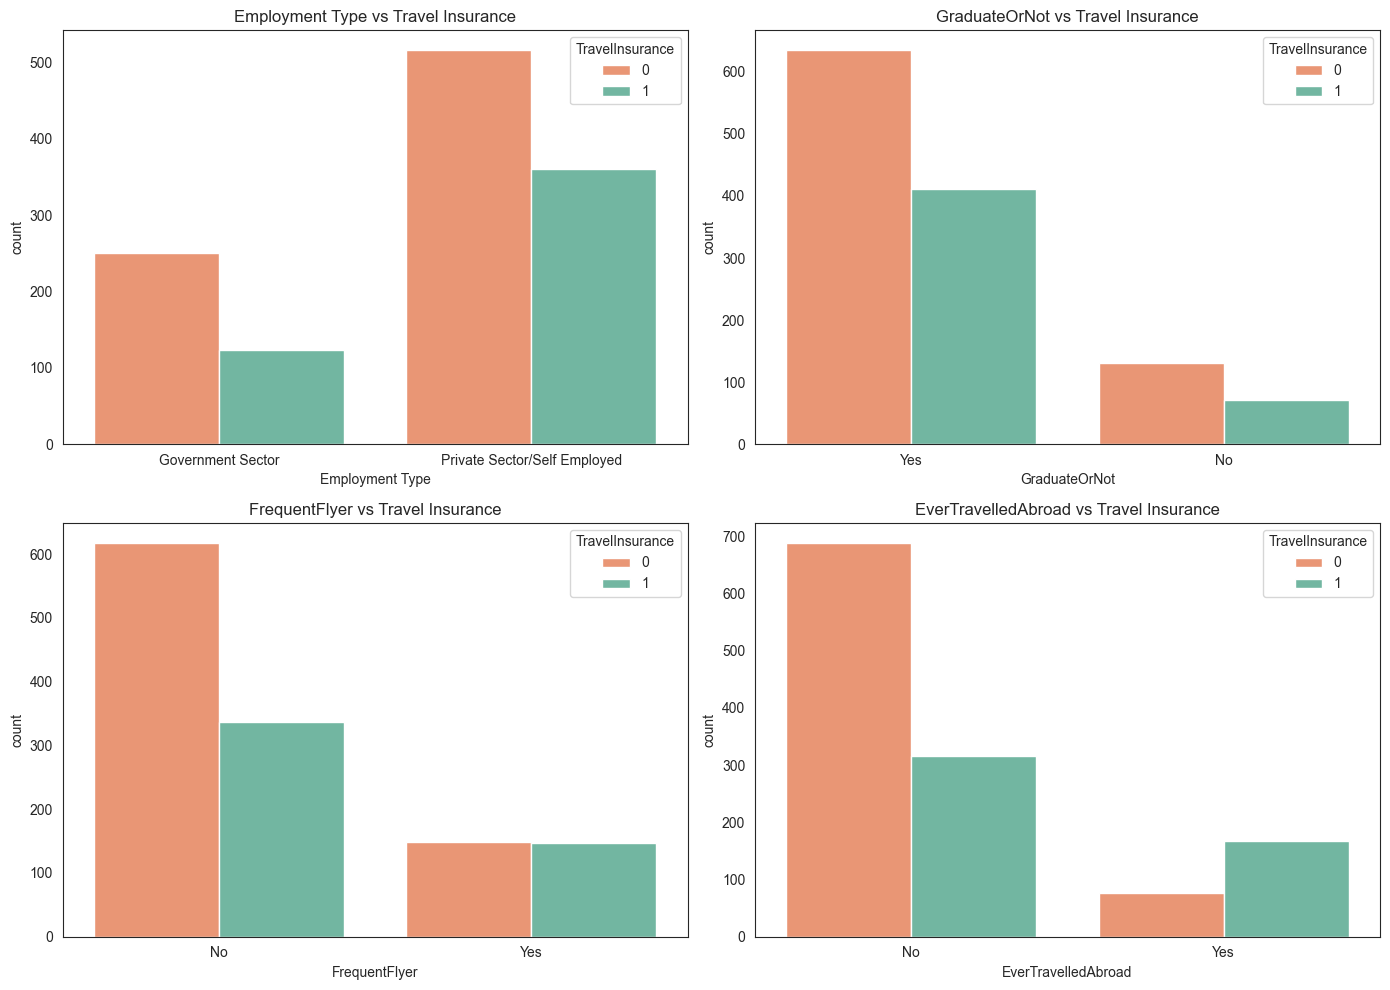

In [11]:
categorical_cols = ['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
colors = sns.color_palette("Set2", n_colors=2)
colors = colors[::-1]

for i, col in enumerate(categorical_cols):
    sns.countplot(data=travel_data, x=col, hue='TravelInsurance', ax=axes[i//2, i%2], palette=colors)
    axes[i//2, i%2].set_title(f'{col} vs Travel Insurance')

plt.tight_layout()
plt.show()

We observe per feature the following: 

**Employment Type:**
- Private Sector/Self Employed customers appear more likely to purchase insurance
- Government Sector employees show lower purchase rates

**GraduateOrNot:** 
- Graduate status shows minimal difference in purchase rates
- Education level alone is not a strong predictor

**FrequentFlyer:** 
- Strong positive correlation with insurance purchase
- Frequent flyers seem to be more likely to buy travel insurance

**EverTravelledAbroad:**
- Strong positive association with insurance purchase
- Customers who have traveled abroad before seem to be much more likely to purchase


For some of those features, we are going to check whether those tendencies are statistically significant.

We come back to the **numerical features:**

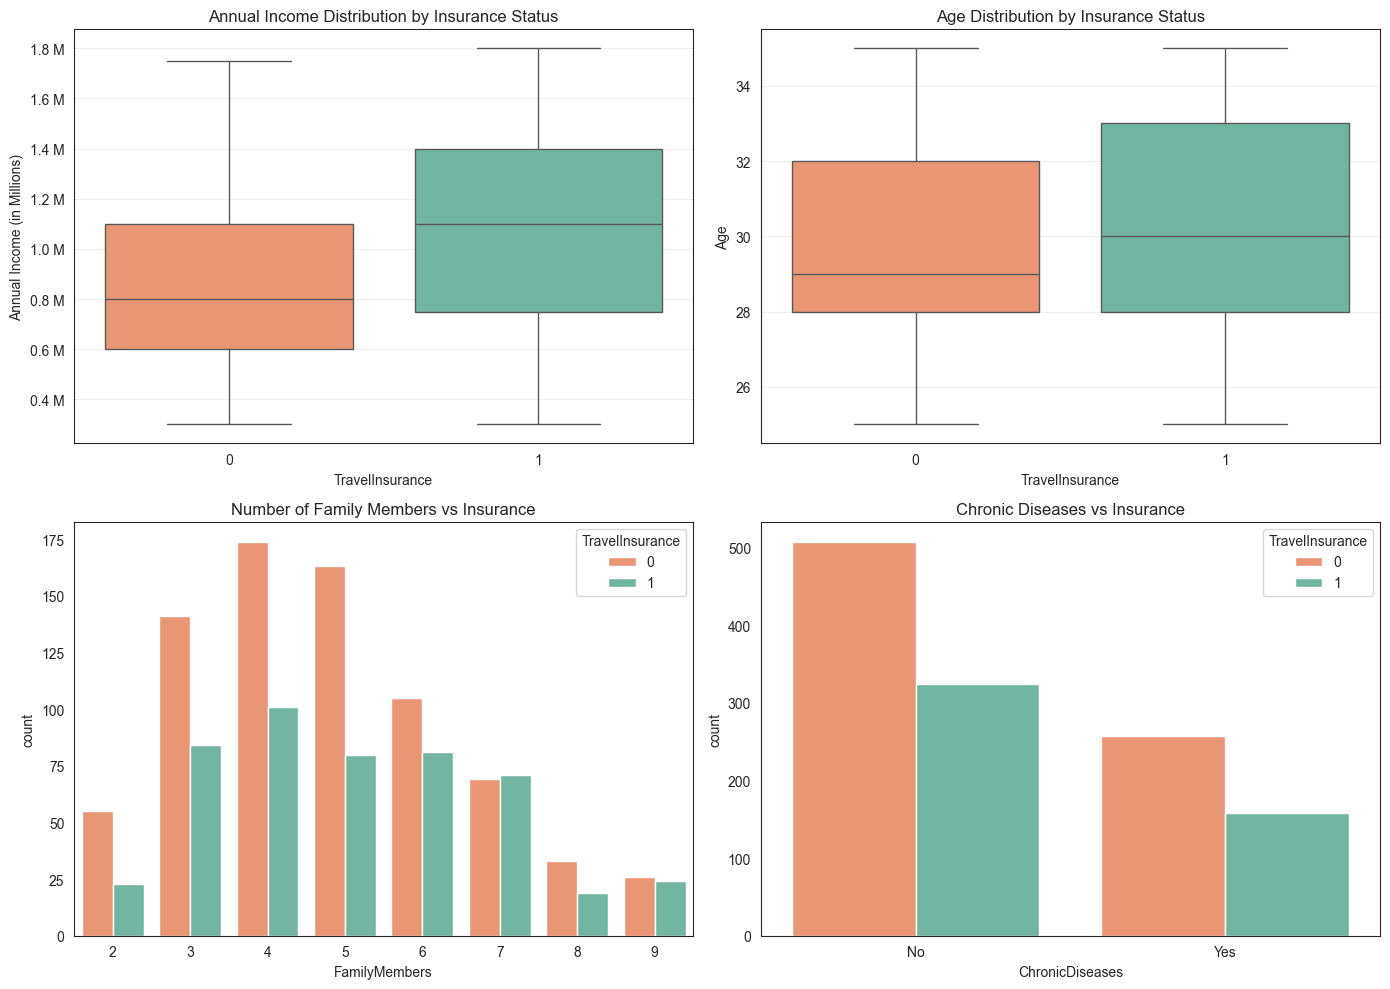

In [12]:
plot_data = travel_data.copy()
plot_data['AnnualIncome_Mio'] = plot_data['AnnualIncome'] / 1000000
colors = sns.color_palette("Set2", n_colors=2)
colors = colors[::-1]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.boxplot(x='TravelInsurance', hue='TravelInsurance', y='AnnualIncome_Mio', data=plot_data, ax=axes[0, 0], palette=colors, legend=False)
axes[0, 0].set_title('Annual Income Distribution by Insurance Status')
axes[0, 0].set_ylabel('Annual Income (in Millions)')

axes[0, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f M'))
axes[0, 0].grid(axis='y', alpha=0.3)

sns.boxplot(x='TravelInsurance', y='Age', data=plot_data, ax=axes[0, 1], palette=colors, hue='TravelInsurance', legend=False)
axes[0, 1].set_title('Age Distribution by Insurance Status')
axes[0, 1].grid(axis='y', alpha=0.3)

sns.countplot(x='FamilyMembers', hue='TravelInsurance', data=plot_data, ax=axes[1, 0], palette=colors)
axes[1, 0].set_title('Number of Family Members vs Insurance')
axes[1, 0].legend(title='TravelInsurance', loc='upper right')

sns.countplot(x='ChronicDiseases', hue='TravelInsurance', data=plot_data, ax=axes[1, 1], palette=colors)
axes[1, 1].set_title('Chronic Diseases vs Insurance')
axes[1, 1].set_xticks([0, 1])
axes[1, 1].set_xticklabels(['No', 'Yes'])
axes[1, 1].legend(title='TravelInsurance', loc='upper right')

plt.tight_layout()
plt.show()

We observe the following: 

**Annual Income:**

- Having a higher annual income seems to be related to a higher chance of buying an insurance 

**Age Distribution:**

- The range given is quite limited and only reflects 25-35, nonetheless having a higher age appears to be more likely to buy an insurance

**Number of Family Members:**

- Buyer share varies across family sizes, but there is no single strong monotonic trend.

**Chronic Diseases:**

- The buyer proportion is similar for customers with and without chronic diseases, suggesting a weak effect.

We analyze the numerical features to check for a **normal (Gaussian) distribution**. We do this because certain algorithms, such as Gaussian Naive Bayes, explicitly assume normally distributed data to perform optimally.

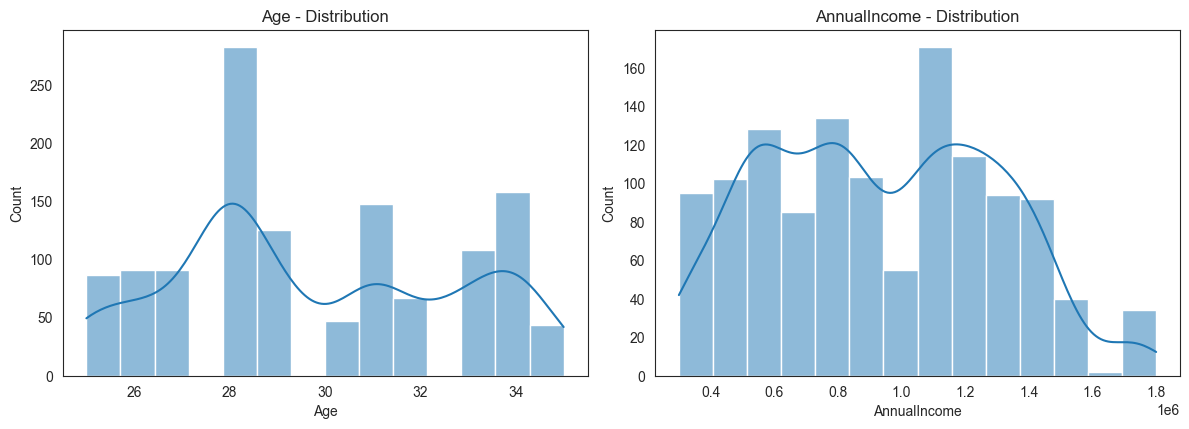

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

sns.histplot(travel_data['Age'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Age - Distribution')

sns.histplot(travel_data['AnnualIncome'], kde=True, ax=axes[0, 1])
axes[0, 1].set_title('AnnualIncome - Distribution')

fig.delaxes(axes[1, 1])
fig.delaxes(axes[1, 0])

plt.tight_layout()
plt.show()

**Observations:**

- **Age**: not normally distributed
- **AnnualIncome**: not normally distributed

**Implications:**
- Models like Gaussian Naive Bayes may not perform optimally with non-Gaussian features
- Tree-based models (RandomForest) are more robust to non-normal distributions

### Summary EDA

Tendencies:

- **Age**: Slightly older customers show a higher purchase rate (within the limited age range).
- **Employment Type**: Buyer share differs by sector.
- **GraduateOrNot**: Weak effect; difference is small.
- **AnnualIncome**: Higher income is associated with higher likelihood of purchase.
- **FamilyMembers**: Buyer share varies by family size, without one dominant pattern.
- **ChronicDiseases**: No strong separation in purchase behavior.
- **FrequentFlyer**: Frequent flyers are more likely to buy insurance.
- **EverTravelledAbroad**: Customers who travelled abroad are more likely to buy insurance.
- **TravelInsurance**: Moderate class imbalance (~39% buyers, ~61% non-buyers).

## Statistical inference

**Target population:** Customers of the travel company who were offered travel insurance in 2019.

In [14]:
print(f"Target population size: {len(travel_data)}")

Target population size: 1249


We are now going to check whether some of the tendencies observed in EDA are statistically significant.

Therefore we're going to iteratively raise and test hypotheses.

We are using the Mann-Whitney U test for the numerical features, which indeed arent normally distributed as seen above. For the categorical ones we are using the z-test for proportions since we are having binary data.

Since our previous checks showed that the numerical data is heavily skewed and not normally distributed, the mean is a misleading metric. Therefore, we use the non-parametric Mann-Whitney U test to compare the rank distributions, which is best represented practically by the median - we therefore are going to use this metric to construct the confidence intervals.

#### Hypothesis 1:

Alternative Hypothesis: Annual Income differs between buyers and non-buyers. The distribution of annual income for buyers is different from that of non-buyers.

Null Hypothesis: There is no difference in annual income distributions between the two groups.

Significance level: 0.05

Test: Mann-Whitney U test

Median (Insurance=0): 800,000
Median (Insurance=1): 1,100,000
Mann-Whitney U-test: U=249205.000, p=3.936e-25


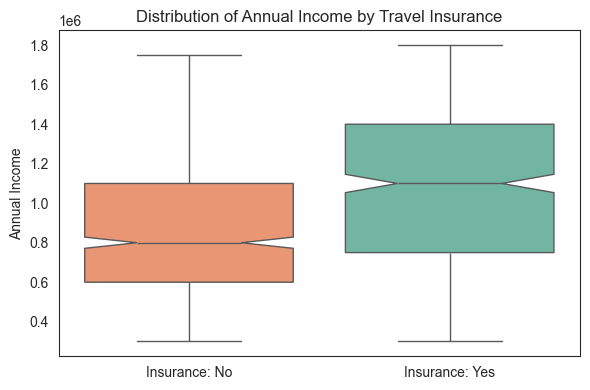

In [44]:
income_yes = travel_data.loc[travel_data['TravelInsurance'] == 1, 'AnnualIncome']
income_no = travel_data.loc[travel_data['TravelInsurance'] == 0, 'AnnualIncome']

result = stats.mannwhitneyu(income_yes, income_no, alternative='two-sided')

print(f"Median (Insurance=0): {income_no.median():,.0f}")
print(f"Median (Insurance=1): {income_yes.median():,.0f}")
print(f"Mann-Whitney U-test: U={result.statistic:.3f}, p={result.pvalue:.3e}")

fig, ax = plt.subplots(figsize=(6, 4))
colors = sns.color_palette("Set2", n_colors=2)[::-1]
sns.boxplot(
    data=travel_data, 
    x='TravelInsurance', 
    y='AnnualIncome', 
    hue='TravelInsurance',
    palette=colors, 
    notch=True,
    legend=False,
    ax=ax
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Insurance: No', 'Insurance: Yes'])
ax.set_xlabel('')
ax.set_ylabel('Annual Income')
ax.set_title('Distribution of Annual Income by Travel Insurance')

plt.tight_layout()
plt.show()

The p value is well below our significance level, which means that we reject our Nullhypothesis and conclude the alternative one. 
The statistic significance gets supported by non overlapping confidence intervals, which we can see above.

#### Hypothesis 2: 

Alternative Hypothesis: The proportion of insurance buyers differs between frequent-flyers and non-frequent-flyers.

Null Hypothesis: There is no difference.

Significance level: 0.05

Test: z-test

TravelInsurance    0    1
FrequentFlyer            
No               618  336
Yes              148  147
Proportion (No): 0.352, 95% CI: [0.322, 0.383]
Proportion (Yes): 0.498, 95% CI: [0.441, 0.555]
Z=-4.503, p=0.000007


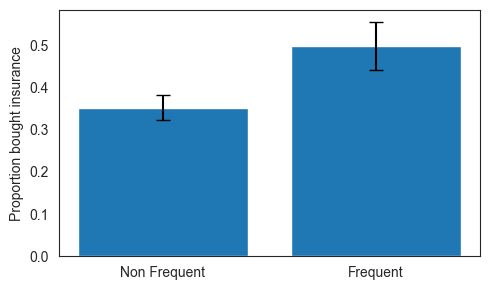

In [17]:
table_ff = pd.crosstab(travel_data['FrequentFlyer'], travel_data['TravelInsurance'])
successes, nobs = table_ff[1], table_ff.sum(axis=1)
z_stat, p_val = proportions_ztest(successes, nobs)
props = successes / nobs
cis = [proportion_confint(s, n) for s, n in zip(successes, nobs)]

print(table_ff)
for i, name in enumerate(table_ff.index):
    print(f"Proportion ({name}): {props.iloc[i]:.3f}, 95% CI: [{cis[i][0]:.3f}, {cis[i][1]:.3f}]")
print(f"Z={z_stat:.3f}, p={p_val:.6f}")

fig, ax = plt.subplots(figsize=(5, 3))
err = [[props.iloc[i] - cis[i][0] for i in range(2)], [cis[i][1] - props.iloc[i] for i in range(2)]]

ax.bar(range(2), props, yerr=err, capsize=5)
ax.set_xticks(range(2))
ax.set_xticklabels(['Non Frequent', 'Frequent'])
ax.set_ylabel('Proportion bought insurance')
plt.tight_layout()
plt.show()

The p value is well below our significance level, which indicates that indeed the proportion of insurance buyers differs statistically significant between frequent-flyers and non-frequent-flyers, we reject the Nullhypothesis.

Building up on what we saw in the EDA:
Frequent Flyers are more likely to buy an insurance. - The proportion of insurance buyers is significantly higher for customers who fly frequently.

#### Hypothesis 3: 

Alternative Hypothesis: The proportion of insurance buyers differs between the ones that have been travelled abroad and the ones that didn't.

Null Hypothesis: There is no difference.

Significance level: 0.05

Test: z-test

TravelInsurance        0    1
EverTravelledAbroad          
No                   689  316
Yes                   77  167
Proportion (No): 0.314, 95% CI: [0.286, 0.343]
Proportion (Yes): 0.684, 95% CI: [0.626, 0.743]
Z=-10.646, p=1.828e-26


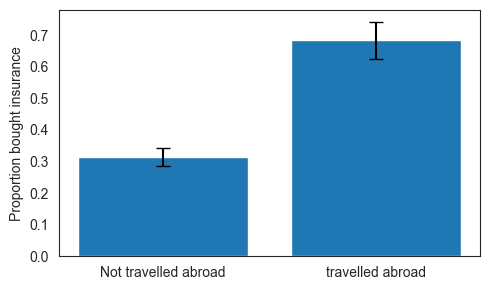

In [18]:
table_abroad = pd.crosstab(travel_data['EverTravelledAbroad'], travel_data['TravelInsurance'])
successes, nobs = table_abroad[1], table_abroad.sum(axis=1)
z_stat, p_val = proportions_ztest(successes, nobs)
props = successes / nobs
cis = [proportion_confint(s, n) for s, n in zip(successes, nobs)]

print(table_abroad)
for i, name in enumerate(table_abroad.index):
    print(f"Proportion ({name}): {props.iloc[i]:.3f}, 95% CI: [{cis[i][0]:.3f}, {cis[i][1]:.3f}]")
print(f"Z={z_stat:.3f}, p={p_val:.3e}")

fig, ax = plt.subplots(figsize=(5, 3))
err = [[props.iloc[i] - cis[i][0] for i in range(2)], [cis[i][1] - props.iloc[i] for i in range(2)]]
ax.bar(range(2), props, yerr=err, capsize=5)
ax.set_xticks(range(2))
ax.set_xticklabels(['Not travelled abroad', 'travelled abroad'])
ax.set_ylabel('Proportion bought insurance')
plt.tight_layout()
plt.show()

Again the p-value is well below our significance level, we reject the Nullhypothesis.

Building up on what we observed in EDA:
Customers who have travelled abroad are more likely to purchase travel insurance than those who have not. - The proportion of insurance buyers is significantly higher for customers who have travelled abroad.

#### Hypothesis 4: 

Alternative Hypothesis: The proportion of insurance buyers differs between graduates and non-graduates.

Null Hypothesis: There is no difference.

Significance level: 0.05

Test: z-test

TravelInsurance    0    1
GraduateOrNot            
No               131   71
Yes              635  412
Proportion (No): 0.351, 95% CI: [0.286, 0.417]
Proportion (Yes): 0.394, 95% CI: [0.364, 0.423]
Z=-1.123, p=0.262


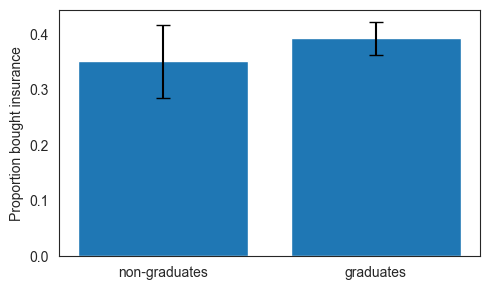

In [19]:
table_grad = pd.crosstab(travel_data['GraduateOrNot'], travel_data['TravelInsurance'])
successes, nobs = table_grad[1], table_grad.sum(axis=1)
z_stat, p_val = proportions_ztest(successes, nobs)
props = successes / nobs
cis = [proportion_confint(s, n) for s, n in zip(successes, nobs)]

print(table_grad)
for i, name in enumerate(table_grad.index):
    print(f"Proportion ({name}): {props.iloc[i]:.3f}, 95% CI: [{cis[i][0]:.3f}, {cis[i][1]:.3f}]")
print(f"Z={z_stat:.3f}, p={p_val:.3f}")

fig, ax = plt.subplots(figsize=(5, 3))
err = [[props.iloc[i] - cis[i][0] for i in range(2)], [cis[i][1] - props.iloc[i] for i in range(2)]]
ax.bar(range(2), props, yerr=err, capsize=5)
ax.set_xticks(range(2))
ax.set_xticklabels(['non-graduates', 'graduates'])
ax.set_ylabel('Proportion bought insurance')
plt.tight_layout()
plt.show()

Our p-value is greater than our significance level - we fail to reject the Nullhypothesis, indicating that the difference in proportion of buyers between graduates and non-graduates is not statistically significant. We also observe overlapping confidence intervals above, supporting and showcasing the test outcome.

#### Hypothesis 5:  

Alternative Hypothesis: Age differs between buyers and non-buyers. The distribution (and median) of age for buyers is different from that of non-buyers.

Null Hypothesis: There is no difference in age distributions between the two groups.

Significance level: 0.05

Test: Mann-Whitney U test

Median (Insurance=0): 29
Median (Insurance=1): 30
Mann-Whitney U-test: U=198733.000, p=2.546e-02


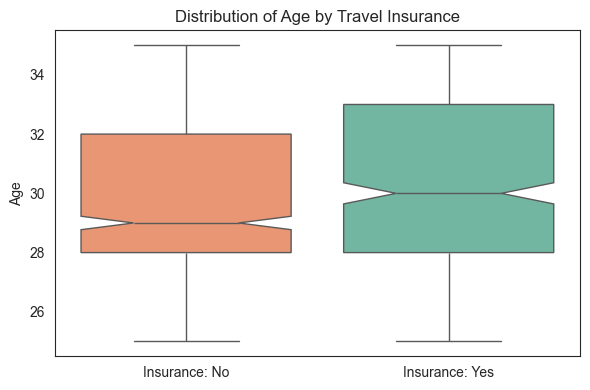

In [42]:
age_yes = travel_data.loc[travel_data['TravelInsurance'] == 1, 'Age']
age_no = travel_data.loc[travel_data['TravelInsurance'] == 0, 'Age']

result = stats.mannwhitneyu(age_yes, age_no, alternative='two-sided')

print(f"Median (Insurance=0): {age_no.median():.0f}")
print(f"Median (Insurance=1): {age_yes.median():.0f}")
print(f"Mann-Whitney U-test: U={result.statistic:.3f}, p={result.pvalue:.3e}")

fig, ax = plt.subplots(figsize=(6, 4))
colors = sns.color_palette("Set2", n_colors=2)[::-1]

sns.boxplot(
    data=travel_data, 
    x='TravelInsurance', 
    y='Age', 
    palette=colors, 
    notch=True,
    ax=ax, 
    legend=False,
    hue='TravelInsurance'
)

ax.set_xticks([0, 1])
ax.set_xticklabels(['Insurance: No', 'Insurance: Yes'])
ax.set_xlabel('')
ax.set_ylabel('Age')
ax.set_title('Distribution of Age by Travel Insurance')

plt.tight_layout()
plt.show()

The p-value is slightly smaller than our significance level, we reject the nullhypothesis and conclude the alternative hypothesis. 
We also observe non overlapping confidence intervals, the difference is quite small, which indicates that while the result is statistically valid, the actual effect size is quite small.

## Modeling

Our case is a binary **classification** - to predict travel insurance purchase, 
we therefore are going to use the following **metrics:**

`Accuracy, F1-score, ROC AUC, Precision-Recall AUC`

We use stratified splits due to the observed class imbalance (~61% vs 39%).

### Split the Data

In [21]:
X = travel_data.drop(columns=['TravelInsurance'])
y = travel_data['TravelInsurance']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)}")
print(f"Test set: {len(X_test)}")

Training set: 999
Test set: 250


### Preprocessing

In [22]:
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer([
    ('num', num_pipeline, make_column_selector(dtype_include='number')),
    ('cat', cat_pipeline, make_column_selector(dtype_include='object'))
])

### Baseline Models

In [23]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier(),
    'NaiveBayes': GaussianNB(),
    'RandomForest': RandomForestClassifier(random_state=42),
}

results = []

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)
    
    y_pred = pipe.predict(X_test)
    
    if hasattr(pipe, "predict_proba"):
        y_score = pipe.predict_proba(X_test)[:, 1]
    else:
        y_score = pipe.decision_function(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    
    results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score),
        'pr_auc': auc(recall, precision)
    })

results_df = pd.DataFrame(results).set_index('model').sort_values('f1_score', ascending=False)
results_df = results_df.round(3)
display(results_df)

,accuracy,f1_score,roc_auc,pr_auc
model,,,,
SVM,0.704,0.513,0.689,0.635
KNN,0.668,0.491,0.644,0.581
RandomForest,0.616,0.461,0.570,0.534
NaiveBayes,0.648,0.457,0.620,0.538
LogReg,0.656,0.456,0.646,0.551


### Light Hyperparameter Tuning

We test small hyperparameter ranges on all models using cross-validation. Our goal here is to find the best models from where we are going to fine-tune them using systematic search techniques.

In [24]:
light_grids = {
    'LogReg': {
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__solver': ['liblinear']
    },
    'SVM': {
        'model__C': [0.01, 0.1, 1, 10, 100],
        'model__kernel': ['linear', 'rbf']
    },
    'KNN': {
        'model__n_neighbors': [1, 3, 5, 7, 9, 11, 15],
        'model__weights': ['uniform', 'distance']
    },
    'NaiveBayes': {
        'model__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6]
    },
    'RandomForest': {
        'model__n_estimators': [50, 100], 
        'model__max_depth': [5, 10]
    }
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
light_results = []

for name, clf in models.items():
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])
    
    grid = GridSearchCV(pipe, light_grids[name], cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    # Our best model
    best_model = grid.best_estimator_
    
    y_pred = best_model.predict(X_test)
    
    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test)[:, 1]
    else:
        y_score = best_model.decision_function(X_test)

    precision, recall, _ = precision_recall_curve(y_test, y_score)
    
    light_results.append({
        'model': name,
        'best_params': grid.best_params_,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score),
        'pr_auc': auc(recall, precision)
    })

light_df = pd.DataFrame(light_results).set_index('model').round(3).sort_values('f1_score', ascending=False)
display(light_df)

,best_params,accuracy,f1_score,roc_auc,pr_auc
model,,,,,
RandomForest,"{'model__max_depth': 5, 'model__n_estimators':...",0.732,0.531,0.679,0.613
SVM,"{'model__C': 1, 'model__kernel': 'rbf'}",0.704,0.513,0.689,0.635
LogReg,"{'model__C': 0.1, 'model__solver': 'liblinear'}",0.660,0.472,0.642,0.546
KNN,"{'model__n_neighbors': 9, 'model__weights': 'u...",0.664,0.468,0.664,0.600
NaiveBayes,{'model__var_smoothing': 1e-09},0.648,0.457,0.620,0.538


The best performing models at this stage are: Random Forest, SVM and Logistic Regression. We therefore continue fine-tuning with them.

### Tuning the Best Models

#### GridSearchCV

For Logistic Regression and Random Forest we are using GridSearchCV, where we test all combinations in a predefined grid, basically in a 'brute force' way.

In [25]:
dense_grids = {
    'LogReg': {
        'model__C': [0.001, 0.01, 0.1, 1, 5, 10, 50, 100], 
        'model__solver': ['liblinear', 'lbfgs'],
        'model__penalty': ['l2']
    },
    'RandomForest': {
        'model__n_estimators': [100, 200, 300],
        'model__max_depth': [10, 20, None],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 4]
    }
}
final_results = []
final_best_models = {}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

target_models_grid = ['LogReg', 'RandomForest']

for name in target_models_grid:
    tuned_name = name + "_Tuned"
    
    clf = models[name]
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])
    grid = GridSearchCV(pipe, dense_grids[name], cv=cv, scoring='f1', n_jobs=-1)
    grid.fit(X_train, y_train)
    
    best_model = grid.best_estimator_
    final_best_models[tuned_name] = best_model
    
    y_pred = best_model.predict(X_test)
    if hasattr(best_model, "predict_proba"):
        y_score = best_model.predict_proba(X_test)[:, 1]
    else:
        y_score = best_model.decision_function(X_test)
        
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    
    final_results.append({
        'model': tuned_name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score),
        'pr_auc': auc(recall, precision)
    })

#### Optuna (Bayesian Optimization)

For SVM we are using Optuna, which is the most effective way to find global minima/maxima.

We do that since the performance of SVM's is highly sensitive to the complex interplay between hyperparameters like C and gamma. GridSearchCV wastes a lot of computing time blindly testing rigid combinations and often misses the optimal settings. As Optuna learns from every test it runs, this saves us computation time while achieving a much more accurate model.

In [26]:
def objective_svm(trial):
    svm_c = trial.suggest_float('model__C', 1e-3, 1e2, log=True)
    svm_kernel = trial.suggest_categorical('model__kernel', ['linear', 'rbf'])
    
    if svm_kernel == 'rbf':
        svm_gamma = trial.suggest_float('model__gamma', 1e-4, 1e-1, log=True)
    else:
        svm_gamma = 'scale'

    clf = SVC(C=svm_c, kernel=svm_kernel, gamma=svm_gamma, probability=True, random_state=42)
    pipe = Pipeline([('prep', preprocessor), ('model', clf)])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1', n_jobs=-1)
    return scores.mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='maximize')
study.optimize(objective_svm, n_trials=30) 

best_params = study.best_params
final_svm = Pipeline([
    ('prep', preprocessor), 
    ('model', SVC(
        C=best_params['model__C'], 
        kernel=best_params['model__kernel'], 
        gamma=best_params.get('model__gamma', 'scale'),
        probability=True, 
        random_state=42
    ))
])

final_svm.fit(X_train, y_train)
final_best_models['SVM_Tuned'] = final_svm

y_pred = final_svm.predict(X_test)
y_score = final_svm.predict_proba(X_test)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, y_score)

final_results.append({
    'model': 'SVM_Tuned',
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_score),
    'pr_auc': auc(recall, precision)
})

final_df = pd.DataFrame(final_results).set_index('model').round(3).sort_values('f1_score', ascending=False)
display(final_df)

,accuracy,f1_score,roc_auc,pr_auc
model,,,,
RandomForest_Tuned,0.740,0.564,0.666,0.604
SVM_Tuned,0.708,0.517,0.694,0.623
LogReg_Tuned,0.648,0.443,0.643,0.546


#### Class Imbalance Handling

As observed in the beginning, we have more non-buyers than buyers in the given dataset. 
To cope with that, we use **Undersampling**, where we randomly remove excess non-buyers to balance the data, and **SMOTE** (Synthetic Minority Over-sampling Technique), where we mathematically generate new, artificial buyer profiles based on the patterns of existing ones. We apply those to the best performing models from above.

In [27]:
target_models = ['LogReg', 'SVM', 'RandomForest']

strategies = {
    '_Undersampling': RandomUnderSampler(random_state=42),
    '_SMOTE': SMOTE(random_state=42)
}

imb_results = []

for model_name in target_models:
    clf = models[model_name]
    
    for suffix, sampler in strategies.items():
        new_name = model_name + suffix
        
        pipe = ImbPipeline([
            ('prep', preprocessor),
            ('sampler', sampler),
            ('model', clf)
        ])
        
        pipe.fit(X_train, y_train)
        
        if new_name in ['SVM_SMOTE', 'LogReg_SMOTE']:
            final_best_models[new_name] = pipe
        
        y_pred = pipe.predict(X_test)
        
        if hasattr(pipe, "predict_proba"):
            y_score = pipe.predict_proba(X_test)[:, 1]
        else:
            y_score = pipe.decision_function(X_test)
            
        precision, recall, _ = precision_recall_curve(y_test, y_score)
        
        imb_results.append({
            'model': new_name,
            'accuracy': accuracy_score(y_test, y_pred),
            'f1_score': f1_score(y_test, y_pred),
            'roc_auc': roc_auc_score(y_test, y_score),
            'pr_auc': auc(recall, precision)
        })

imb_df = pd.DataFrame(imb_results).round(3).sort_values('f1_score', ascending=False).set_index('model')
display(imb_df)

,accuracy,f1_score,roc_auc,pr_auc
model,,,,
SVM_SMOTE,0.712,0.556,0.700,0.657
SVM_Undersampling,0.696,0.548,0.704,0.655
LogReg_SMOTE,0.620,0.527,0.645,0.545
LogReg_Undersampling,0.624,0.520,0.650,0.551
RandomForest_Undersampling,0.608,0.500,0.601,0.557
RandomForest_SMOTE,0.632,0.489,0.564,0.517


#### Ensemble

Now we take the best models from our top models so far and combine them. We use Soft Voting, where we average the predicted probabilities of each model to make a final, rather balanced prediction.

In [28]:
best_models_for_ensemble = {
    'RandomForest_Tuned': final_best_models['RandomForest_Tuned'],
    'SVM_SMOTE': final_best_models['SVM_SMOTE'],
    'LogReg_SMOTE': final_best_models['LogReg_SMOTE']
}

estimators_list = list(best_models_for_ensemble.items())

ensemble = VotingClassifier(estimators=estimators_list, voting='soft', n_jobs=-1)
ensemble.fit(X_train, y_train)

y_pred = ensemble.predict(X_test)
y_score = ensemble.predict_proba(X_test)[:, 1]

precision, recall, _ = precision_recall_curve(y_test, y_score)

final_results.append({
    'model': 'Ensemble_Voting',
    'accuracy': accuracy_score(y_test, y_pred),
    'f1_score': f1_score(y_test, y_pred),
    'roc_auc': roc_auc_score(y_test, y_score),
    'pr_auc': auc(recall, precision)
})

final_df = pd.DataFrame(final_results).set_index('model').round(3).sort_values('f1_score', ascending=False)
final_df = final_df.fillna('-')
display(final_df)

,accuracy,f1_score,roc_auc,pr_auc
model,,,,
RandomForest_Tuned,0.740,0.564,0.666,0.604
Ensemble_Voting,0.696,0.548,0.683,0.601
SVM_Tuned,0.708,0.517,0.694,0.623
LogReg_Tuned,0.648,0.443,0.643,0.546


Finally take a look at all the models trained to have a broader overview.

In [29]:
final_best_models['Ensemble_Voting'] = ensemble

all_models_results = []

for name, model in final_best_models.items():
    y_pred = model.predict(X_test)
    
    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)
    
    precision, recall, _ = precision_recall_curve(y_test, y_score)
    
    all_models_results.append({
        'model': name,
        'accuracy': accuracy_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_score),
        'pr_auc': auc(recall, precision)
    })

all_models_df = pd.DataFrame(all_models_results).set_index('model').round(3).sort_values('f1_score', ascending=False)
display(all_models_df)

,accuracy,f1_score,roc_auc,pr_auc
model,,,,
RandomForest_Tuned,0.740,0.564,0.666,0.604
SVM_SMOTE,0.712,0.556,0.700,0.657
Ensemble_Voting,0.696,0.548,0.683,0.601
LogReg_SMOTE,0.620,0.527,0.645,0.545
SVM_Tuned,0.708,0.517,0.694,0.623
LogReg_Tuned,0.648,0.443,0.643,0.546


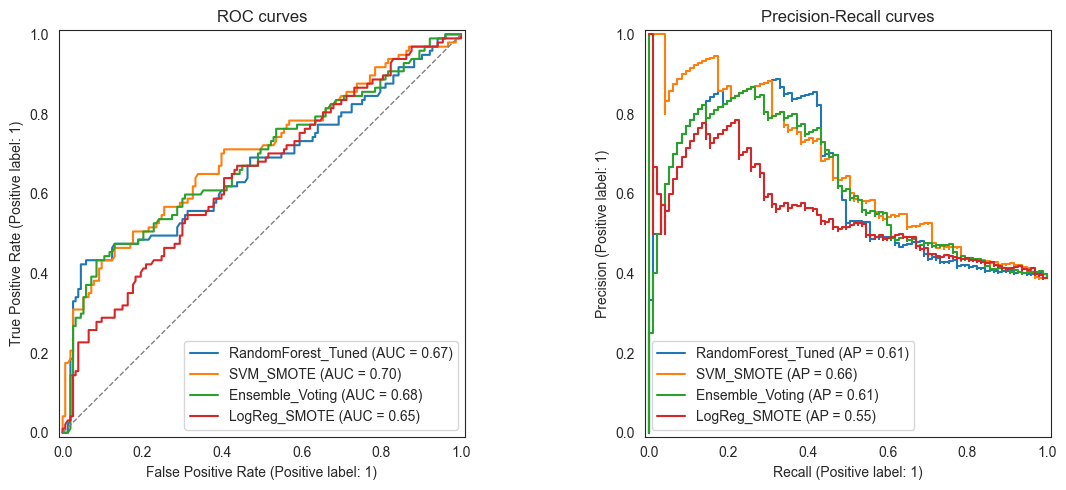

In [30]:
top_models = list(all_models_df.head(4).index)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name in top_models:
    model = final_best_models[name]

    if hasattr(model, 'predict_proba'):
        y_score = model.predict_proba(X_test)[:, 1]
    else:
        y_score = model.decision_function(X_test)

    RocCurveDisplay.from_predictions(y_test, y_score, name=name, ax=axes[0])
    PrecisionRecallDisplay.from_predictions(y_test, y_score, name=name, ax=axes[1])

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', linewidth=1)
axes[0].set_title('ROC curves')
axes[1].set_title('Precision-Recall curves')
axes[1].legend(loc='lower left')
plt.tight_layout()
plt.show()

**ROC:**
We observe that the models separate the classes well overall - the curves somewhat stretch out towards the top-left corner.

**Precision Recall:**
The curves highlight the following trade-off: as we capture more actual buyers (Recall), our prediction accuracy (Precision) drops significantly, which explains our F1-scores of around 0.55.

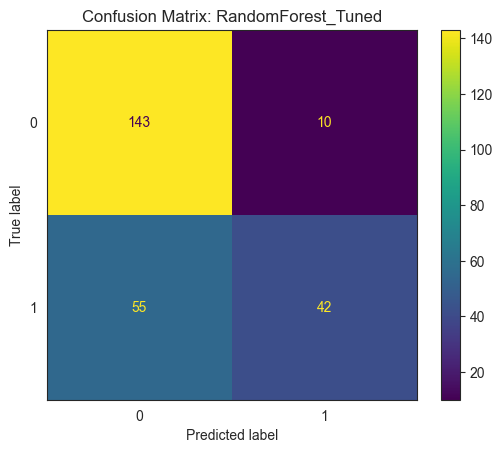

Best model: RandomForest_Tuned
Best metrics: {'accuracy': 0.74, 'f1_score': 0.564, 'roc_auc': 0.666, 'pr_auc': 0.604}


In [31]:
best_name = final_df.index[0]
best_model = final_best_models[best_name]

ConfusionMatrixDisplay.from_estimator(best_model, X_test, y_test)
plt.title(f'Confusion Matrix: {best_name}')
plt.show()

print('Best model:', best_name)
print('Best metrics:', final_df.loc[best_name].to_dict())

## Model Selection

We select the model with the highest F1-score, as it provides the best balance between precision and recall for our imbalanced dataset.

### Sample prediction

Below we demonstrate a single prediction using the best performing model. This shows how the model would classify a new customer.

In [32]:
sample_idx = X_test.sample(n=1, random_state=42).index[0]
sample_X = X_test.loc[[sample_idx]]
sample_y_true = y_test.loc[sample_idx]

print("Sample customer profile:")
print(sample_X.T)

Sample customer profile:
                                             1063
Age                                            28
Employment Type      Private Sector/Self Employed
GraduateOrNot                                 Yes
AnnualIncome                              1150000
FamilyMembers                                   7
ChronicDiseases                                 1
FrequentFlyer                                  No
EverTravelledAbroad                            No


In [33]:
y_pred_sample = best_model.predict(sample_X)[0]
y_prob = best_model.predict_proba(sample_X)[0]
prob_str = f"Probability: {y_prob[1]:.1%} (class 1)"

print(f"Best model: {best_name}")
print(f"Prediction: {y_pred_sample} {'(Would buy insurance)' if y_pred_sample == 1 else '(Would NOT buy insurance)'}")
print(f"Actual: {sample_y_true} {'(Bought insurance)' if sample_y_true == 1 else '(Did NOT buy insurance)'}")
if prob_str:
    print(prob_str)
print(f"Correct: {'Yes' if y_pred_sample == sample_y_true else 'No'}")

Best model: RandomForest_Tuned
Prediction: 0 (Would NOT buy insurance)
Actual: 0 (Did NOT buy insurance)
Probability: 29.2% (class 1)
Correct: Yes


## Conclusion

In this analysis, we built and evaluated multiple machine learning models to predict travel insurance purchase behavior. Our key findings:

### Summary of Findings

1. **EDA Insights**:
   - The dataset has moderate class imbalance (~61% non-buyers vs ~39% buyers).
   - Higher income and slightly higher age are associated with higher purchase rates.
   - Frequent flyers and customers who travelled abroad show clearly higher buyer proportions.

2. **Statistical Inference**:
   - Welch t-tests indicate significant differences in **AnnualIncome** and **Age** between buyers and non-buyers.
   - Proportion z-tests show significant differences for **FrequentFlyer** and **EverTravelledAbroad**.
   - **GraduateOrNot** is not statistically significant at the 5% level.

3. **Modeling**:
   - The strongest single model is **RandomForest_Tuned** (best F1 among baseline/tuned models).
   - Sampling improved linear and SVM variants; **SVM_SMOTE** and **LogReg_SMOTE** outperformed their non-sampled tuned versions.
   - A soft-voting ensemble of selected best variants achieved stable, moderate overall performance.

### Limitations and Improvements
- The dataset is relatively small (< 2000 samples after removing duplicates).
- Features are limited; more customer behavior/history variables could improve prediction quality.
- Overall performance is moderate, so there is still room to improve precision-recall balance.
- Explore alternative evaluation setups (e.g., macro-F1 and threshold tuning).
- Add targeted feature engineering.
- multicollinearity, non-linear correlations